In [38]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [39]:
train_dataset = datasets.MNIST(root='../../datasets', train = True, download = True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root = '../../datasets', train = False, download = True, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [40]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 10)
        )
    
    def forward(self, x):
        return self.sequential(x)

In [41]:
model = Model()
model.train()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

loss_list = []

for epoch in range(10):
    loss_sum = 0
    batch_num = 0
    
    for images, labels in train_loader:
        batch_num += 1
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss_sum += loss.item()
        loss.backward()
        optimizer.step()
    
    
    print(f"({epoch}) : {loss_sum/batch_num}")
    loss_list.append(loss_sum/batch_num)


(0) : 0.5431573658164884
(1) : 0.32256217601139153
(2) : 0.2953427288609781
(3) : 0.2818569094578086
(4) : 0.27349566766765837
(5) : 0.26796848602545287
(6) : 0.263124858678531
(7) : 0.2601158517375112
(8) : 0.25727563487218896
(9) : 0.2550599206246928


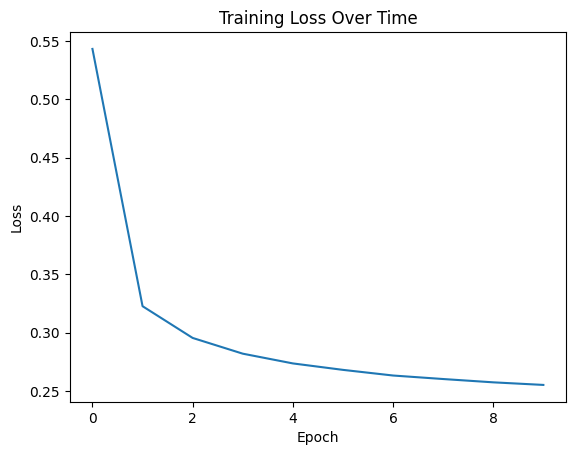

In [42]:
plt.plot(loss_list)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [44]:
model.eval()

correct = 0
samples = 0

preds = []
true = []

for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        samples += labels.size(0)
        
        preds.extend(predicted.tolist())
        true.extend(labels.tolist())
        
accuracy = correct/samples
print(accuracy)
        

0.9274


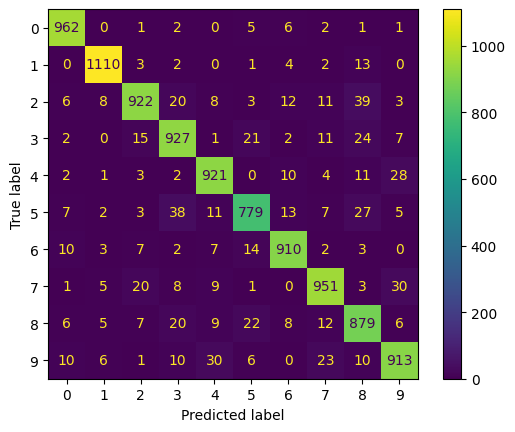

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
disp.plot()
plt.show()
